# 🧪LAB: Partial Least Squares Regression

In this lab, you will explore **Partial Least Squares (PLS) Regression**, a powerful technique for modeling relationships between high-dimensional, collinear predictors and a continuous outcome. You will begin with a **group discussion** after reading about the method. Next, you will become familiar with its implementation in `scikit-learn` by **recreating and reflecting on one of their tutorials**. Finally, you will apply PLS to a **real-world chemoinformatics dataset** that includes binary molecular fingerprints as predictors and a continuous permeability outcome for a set of chemical compounds.

PLS is particularly useful when the number of predictors is large and highly correlated, making traditional regression methods unstable or ineffective. You will also compare PLS with an alternative predictive model that also involves a dimensionality-reduction approach: **Penalized Principal Component Regression (PCR)**.

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

--- 

In total, this lab assignment will be worth **100 points**.

## 1. Reading & Group Discussion (10 Points)

Carefully read **Sections 6.2 and 6.3** of the *An Introduction to Statistical Learning* book (Reference B). The first section introduces Principal Component Regression (PCR), which we already covered in a previous class. The second section, instead, introduces Partial Least Squares (PLS).

After reviewing the content, discuss with your group and then answer the following questions:

a. What is the key difference between Principal Component Regression (PCR) and Partial Least Squares (PLS)

**PCR is an unsupervised dimension-reduction method which constructs its components (principal components) using only predictor variables, without any reference to the response Y. PLS is a supervised dimension-reduction method, which constructs its components using both the predictors and the response, specifically searching for directions that are correlated with Y.**

b. Why might PCR fail to find directions that are useful for predicting the response `Y`? 

**The book explains that PCR's directions are identified in an unsupervised way, the response Y is never used to help determine the principal component directions. Because of this, PCR has a drawback: there's no guarantee that the directions which best explain the predictors will also be the best directions for predicting the response. A direction can capture a lot of variance in X while having little or nothing to do with Y, and PCR has no way to detect or avoid this since it never looks at Y when building its components.**

c. In PLS, how is the first direction `Z₁` computed? 

**First, all the predictors are standardized. Then, for each predictor, PLS runs a simple one-variable regression of Y on that predictor and uses the resulting coefficient as the weight for that predictor. This coefficient is basically a stand-in for how correlated that predictor is with Y. So when Z₁ is built as a weighted sum of all the predictors, the ones most strongly correlated with Y get the biggest weights, and the ones barely related to Y get very small weights.**

d. What are some similarities and differences between PLS and penalized regression? 

**Both methods are trying to solve the same problem: too many predictors that are highly correlated, which makes regular least squares unstable. They also both have something you have to tune (how many PLS components vs. how strong the ridge/lasso penalty is), and you usually pick that with cross-validation. The book says that in practice, PLS usually doesn't beat ridge. They tend to perform about the same. Using Y to pick the PLS components can lower bias compared to PCR, but it also raises variance, so the benefit of PLS over PCR often cancels out. That's why PLS typically doesn't outperform ridge or PCR either.**

**The difference is how they get there. Ridge and lasso keep the original predictors and just shrink their coefficients toward zero (lasso can even drop some variables by setting coefficients to exactly zero). PLS instead builds new combined variables first, then regresses Y on those. Those combined variables still usually include all the original predictors, so PLS isn't really doing variable selection the way lasso is.**

## 2. Recreate, Explain, Experiment & Reflect (35 points)

Follow this tutorial on Partial Least Squares (PLS) from the official scikit-learn documentation:

📘 [scikit-learn: PLS regression example](https://scikit-learn.org/stable/auto_examples/cross_decomposition/plot_pcr_vs_pls.html)

Your goal is to **recreate the PLS portion of the tutorial in this notebook**, and make sure you understand what each part of the code is doing. This will give you the opportunity to build intuition for how PLS works. Be thorough in your answers and interpretations — this will help you when working with real data later in this lab assignment.

### a. Recreate
- Load the dataset used in the tutorial. Make sure to create a training/reporting partition.
- Fit a `PLSRegression` model with 1 component. 

In [ ]:
# YOUR CODE HERE
# PART 1
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split

# PART 2
# Pasted from tutorial
rng = np.random.RandomState(0)
n_samples = 500
cov = [[3, 3], [3, 4]]
X = rng.multivariate_normal(mean=[0, 0], cov=cov, size=n_samples)
pca = PCA(n_components=2).fit(X)
y = X.dot(pca.components_[1]) + rng.normal(size=n_samples) / 2

# PART 3
# For visualization purposes, turn into pandas dataframe
df = pd.DataFrame(X)
print(df.head())


# PART 4
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = rng)
pls_model = PLSRegression(n_components = 1) # tutorial mentions pls scales by default so no pipeline
pls_model.fit(X_train, y_train)
print(f"PLS r-squared {pls_model.score(X_test, y_test):.3f}")

          0         1
0 -3.123062 -3.267402
1 -2.775958 -0.929101
2 -2.582416 -4.072345
3 -1.492453 -1.920361
4 -0.041529  0.381166
PLS r-squared 0.658


### b. Explain
For **every block of code**, add a markdown cell that explains:

- What is the goal of this step?
- Why is this important in a PLS regression pipeline?
- What does the output mean or tell us?

PART 1
- The goal of this step is to import every necessary package, module, or class in. Numpy was used to generate the random dataset, pandas was used to make a cleaner dataframe so I can better understand the dataset, PCA was used to make the fake y that correlates with PC2, PLS Regression is used to run dimension reduction and to create a model, and train_test_split was added to create a comparable test set and to get a model score. 
- This is important in the PLS regression pipeline because each step sets the foundation for any analysis. Basic tools like pandas and numpy are there to create the fake dataset. PCA is not necessary in most PLS regressions, however, for reproducibility on account of the tutorial, I kept it. PLS Regression is important because this is a PLS regression pipeline. Train test split is important because it allows us to split the fake set into 2 sections, one for testing and the other one for training the model. This also allows us to get a error score and see if the model is good or not. 
- The output is not printed but all the imports allows me to use any packages, classes, or modules listed above. Using packages makes running PLS regression easier because instead of handcoding everything, I can just run a couple lines of code from these packages. It is a neater and more efficient way to run PLS regression. 

PART 2
- The goal of this step is to create a fake dataset including 2 columns of the predictor X and 1 column of the target variable y. The rng is set to 0 for reproducibility. The usage of multivariable_normal gives us a normal distribution dataset that allows for multiple variables (the 2 columns of X), and both columns are centered on the mean 0. The cov describes the variance between each X and how strongly they are related to each other. The sample size tells the generator to generalize 500 samples. Once the predictors are created, a PCA is ran on it and PC1 and PC2 are found. Then, the target variable y is created relying on PC2 and some noise. This just makes y correlated with PC2 rather than PC1 to illustrate how larger variance does not equal larger correlation. Some noise is also added to y so it's not the exact same as PC2. 
- This is important in a PLS regression pipeline because a PLS regression needs to be ran on a dataset. We need predictors and a target variable because in PLS, the PLS is supervised which means it needs the target variable to generate the pls. In this case, we used a fake y that depends on PC2, however, in normal cases, there is no way of telling what it's more correlated to. 
- The output is a dataset X with the shape (500, 2) meaning 500 rows and 2 columns. The other output is the 1D array y. These can be used later in modeling and regression. 

PART 3
- The goal of this step was to turn it into a familiar format so that I can better understand the code. 
- This is important because I need to learn PLS regression and understanding the dataset is very important. 
- The output tells us what the basic shape of the dataset is like. It also gives me a more concrete idea of what the data centered around the mean 0 looks like. 

PART 4
- The goal of this step is to create the model and test it's efficiency. First, the dataset is split into a train set and a test set so that we can test the train set against the test set later to see how good the model does against unseen data. Then the regression model is created using the imported class with the component set to 1 which only creates 1 PLS. This does not need to be standardized because PLSRegression automatically standardizes the dataset. Finally, the model fits and learns from the training set and a model score is generated to test how good it is.
- This is important because the model needs to learn from a portion of the dataset before it can be used to create PLS. PLS needs to learn the behavior of both the x and y because rather than rely on variance, PLS components want correlation with Y. This part is crucial for the model because once the model learns the regression relationship between X and y, it can later be used to create predictions. In the tutorial, predict was never used to generate a predicted y set, but the PLS1 is used to generate the predicted y set. The test at the end is important too because it shows how well the model can predict the test set initially set aside. 
- The output is a fitted PLS regression model that has a r-squared of 0.658. The model itself learned PLS1 and can be used to make predictions. The r-squared score tests the predicted scores against the test set. The predicted scores are generated from the model automatically when .score is called. 

### c. Experiment
Make the following changes:
- Change the number of components to **2 components** and fit again the model.
- Plot the **predicted vs. actual** response values on the reporting set.
- Report **R²** and **Mean Squared Error (MSE)** for your model
- On the reporting set, create scatter plots showing each component on X against y. (Hint: Use the `transform` method applied to X to get each component). In the title, show the correlation coefficient between both variables. Your first component should correlate more (in magnitude) with the outcome.

In [32]:
# YOUR CODE HERE
from sklearn.metrics import mean_squared_error

pls_model_2 = PLSRegression(n_components = 2) 
pls_model_2.fit(X_train, y_train)
y_pred_2 = pls_model_2.predict(X_test)


print(f"PLS r-squared {pls_model_2.score(X_test, y_test):.3f}")
print(f"PLS MSE: {mean_squared_error(y_test, y_pred_2):.3f}")

PLS r-squared 0.673
PLS MSE: 0.217


TypeError: 'str' object is not callable

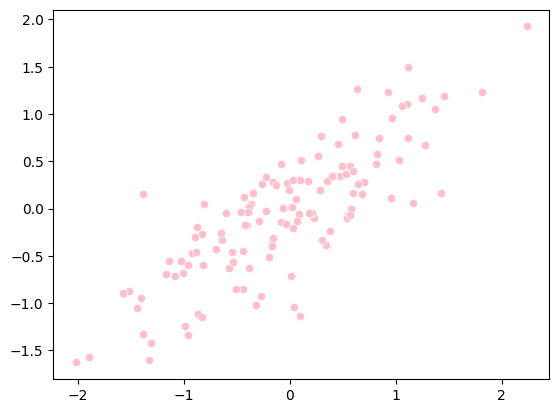

In [33]:
# Predicted vs Actual response values on reporting set
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x = y_test, y = y_pred_2, color = 'pink')
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.show()

### d. Reflect
Finally, answer these questions:

- What do the learned PLS components represent in your dataset?
- Did increasing the number of components improve performance?
- What makes PLS different from PCA?

YOUR TEXT HERE

## 3. PLS on real data: Molecular Fingerprints and Permeability (50 points)

In this final part of the lab, you will apply PLS Regression to a real-world, high-dimensional dataset from pharmaceutical research.

The goal is to build a predictive model of compound permeability—a key property that determines a molecule’s ability to cross biological membranes such as the intestinal wall or the blood–brain barrier. Permeability is critical in drug development, as compounds that cannot reach their target tissues may ultimately fail despite promising initial results.

You will work with a dataset containing 165 compounds characterized by 1,107 binary molecular fingerprints, which indicate the presence or absence of specific chemical substructures. Your task is to use PLS to predict each compound's permeability and evaluate whether such a model could serve as a computational alternative to expensive, labor-intensive lab assays.

Here the link to the dataset: https://github.com/UVADS/DS-4021/blob/84e85842222820f6d60bfdfd051c6d1556d98479/datasets/lab01_data.csv

### a. Prepare data

- Load the dataset.
- Separate the molecular fingerprint variables (`X`) from the permeability values (`y`).
- Split the data into training and reporting sets (e.g., 70/30 split).

### b. Create a pipeline.

Create a pipeline that includes the following: 

- A variance thresholding step to remove near-constant binary features, since molecular fingerprints are typically sparse.
(Hint: you may want to check the `feature_selection` module in `scikit-learn`.)
- A standardization step.
- The Partial Least Squares Regression method.

### c. Optimize and train.

After you create the pipeline, you should optimize (using cross-validation) and train your pipeline. Your optimization should tune the number of PLS components. After training, report:

- The number of predictors remaining after the variance thresholding step
- The selected number of PLS components
- The cross-validated **R²** on the training set.


### d. Evaluate

- Use the best PLS model to predict permeability on the reporting set
- Report the reporting set R²

### e. Compare.

- Compare with the performance obtained using a penalized principal component regression. You may experiment with Lasso, Ridge or/and ElasticNet. Make sure to encapsulate this model into a pipeline and optimize it as well.


### f. Reflect

Discuss:
- Which model performed best?
- Would you trust any of your models enough to replace the permeability lab assay?
- What would be the trade-offs of doing so?

In [3]:
# A. Prepare Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

df = pd.read_csv("https://github.com/UVADS/DS-4021/blob/84e85842222820f6d60bfdfd051c6d1556d98479/datasets/lab01_data.csv?raw=true")

X = df.drop(columns=["permeability"])
y = df["permeability"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [4]:
# B. Create a pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pls_regressor = Pipeline([
    ("selector", VarianceThreshold(threshold=0.01)),
    ("scaler", StandardScaler()),
    ("pls", PLSRegression()),
])

pls_regressor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('selector', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.01
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",2
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500


In [5]:
# C. Optimize and train
from sklearn.model_selection import GridSearchCV, KFold

inner_cv = KFold(n_splits=5, shuffle=True, random_state=1234)
candidate_grid = {"pls__n_components": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20]}

pls_search = GridSearchCV(
    estimator=pls_regressor,
    param_grid=candidate_grid,
    scoring="r2",
    cv=inner_cv,
    n_jobs=-1,
)
pls_search.fit(X_train, y_train)

n_selected_features = pls_search.best_estimator_["selector"].get_support().sum()
n_selected_components = pls_search.best_params_['pls__n_components']
best_cv_r2 = pls_search.best_score_

print(f"Predictors remaining after variance thresholding step: {n_selected_features}")
print(f"Selected number of PLS components: {n_selected_components}")
print(f"Best cross-validated R2 on training set: {best_cv_r2:.2f}")

cv_results = pd.DataFrame(pls_search.cv_results_)
cv_results[["param_pls__n_components", "mean_test_score", "std_test_score"]]

Predictors remaining after variance thresholding step: 676
Selected number of PLS components: 2
Best cross-validated R2 on training set: 0.25


,param_pls__n_components,mean_test_score,std_test_score
0,1,0.190718,0.479164
1,2,0.252183,0.397165
2,3,0.159224,0.506268
3,4,0.204877,0.423482
4,5,0.213215,0.425721
5,6,0.176573,0.462791
6,7,0.151798,0.371665
7,8,0.123421,0.417698
8,9,0.079838,0.505087
9,10,0.101020,0.478924


In [6]:
# D. Evaluate
from sklearn.metrics import r2_score

final_pls_pipeline = pls_search.best_estimator_
testing_preds = final_pls_pipeline.predict(X_test)
testing_r2 = r2_score(y_test, testing_preds)

print(final_pls_pipeline)
print(f"Final testing R2: {testing_r2:.2f}")

Pipeline(steps=[('selector', VarianceThreshold(threshold=0.01)),
                ('scaler', StandardScaler()), ('pls', PLSRegression())])
Final testing R2: 0.33


In [7]:
# E. Compare
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV

# Block warning spam
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

alphas = np.logspace(-4, 2, 100)
candidate_grid = {"pca__n_components": [2, 5, 10, 15, 20]}

for penalty, name in zip(
    [LassoCV(alphas=alphas, cv=inner_cv), RidgeCV(alphas=alphas, cv=inner_cv), ElasticNetCV(alphas=alphas, cv=inner_cv)],
    ["PCR + Lasso", "PCR + Ridge", "PCR + ElasticNet"]):

    pcr_regressor = Pipeline([
        ("selector", VarianceThreshold(threshold=0.01)),
        ("scaler", StandardScaler()),
        ("pca", PCA()),
        ("penalized_regressor", penalty),
    ])

    pcr_search = GridSearchCV(
        estimator=pcr_regressor,
        param_grid=candidate_grid,
        scoring="r2",
        cv=inner_cv,
        n_jobs=-1,
    )
    pcr_search.fit(X_train, y_train)

    pcr_testing_r2 = r2_score(y_test, pcr_search.best_estimator_.predict(X_test))

    print(f"{name}:"
          f"\nSelected number of components: {pcr_search.best_params_['pca__n_components']}"
          f'\nBest cross-validated R2 = {pcr_search.best_score_:.2f}'
          f'\nFinal testing R2 = {pcr_testing_r2:.2f}\n')

print(f"PLS: best cross-validated R2 = {pls_search.best_score_:.2f}, final testing R2 = {testing_r2:.2f}")

PCR + Lasso:
Selected number of components: 10
Best cross-validated R2 = 0.23
Final testing R2 = 0.37

PCR + Ridge:
Selected number of components: 10
Best cross-validated R2 = 0.27
Final testing R2 = 0.39

PCR + ElasticNet:
Selected number of components: 10
Best cross-validated R2 = 0.26
Final testing R2 = 0.38

PLS: best cross-validated R2 = 0.25, final testing R2 = 0.33


### f. Reflect

**Which model performed the best?**

PCR + Ridge did the best, with the highest cross validated R² (0.27) and the highest test R² (0.39). All three PCR models beat PLS, which only got a test R² of 0.33. This matches what we read earlier, since PLS usually doesn't beat ridge regression in practice.

**Would you trust any of your models enough to replace the permeability lab assay?**

Not really. An R² of about 0.33 to 0.39 means the model only explains a third to less than half of what's actually going on with permeability. That's not accurate enough to fully replace lab testing, especially since a wrong prediction could mean dropping a good compound or moving forward with a bad one.

**What would be the trade-offs of doing so?**

Using the model instead of lab testing would save a lot of time and money, but it would be less accurate. A better use of the model would be to help decide which compounds are worth testing in the lab, instead of replacing the lab test completely. Also, with only 165 compounds and over a thousand features, the model might not work as well on new compounds, which shows up in the fairly high variation in the cross validation scores. Lastly, the model's results are harder to interpret than a real lab measurement, since PCR and PLS combine many features together instead of keeping them separate.

## 4. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

YOUR TEXT HERE